## Data Cleaning ##

In [ ]:
import pandas as pd
import re

df = pd.read_csv(r"D:\ML\spam_ham_dataset.csv\spam_ham_dataset.csv")


df = df.drop(columns=['Unnamed: 0', 'label_num'])

df_clean = (
    df.dropna(subset=["text", "label"])
    .drop_duplicates(subset="text")
    .reset_index(drop=True) 
)


df_clean["label"] = df_clean["label"].str.lower()
df_clean["label_num"] = df_clean["label"].map({"spam": 1, "ham": 0})

def clean_text(text):
    
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    
    text = text.replace('\\r\\n', ' ').replace('\\n', ' ').replace('\\r', ' ')
    
    text = re.sub(r'\s+', ' ', text)
    
    text = text.strip()
    
    text = text.lower()
    
    return text

df_clean["text_cleaned"] = df_clean["text"].apply(clean_text)

print("Class distribution:")
print(df_clean["label"].value_counts())
print(f"\nClass balance: {df_clean['label'].value_counts(normalize=True)}")

# Save cleaned data
df_clean.to_csv(r"D:\ML\spam_h am_cleaned.csv", index=False)

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Class distribution:
label
ham     3531
spam    1462
Name: count, dtype: int64

Class balance: label
ham     0.70719
spam    0.29281
Name: proportion, dtype: float64

Original shape: (5171, 2)
Cleaned shape: (4993, 4)
Rows removed: 178


## Train test split ##

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
#load the model
df = pd.read_csv(r"D:\ML\spam_ham_cleaned.csv")
df = df.dropna(subset=["text_cleaned", "label_num"]).reset_index(drop=True)
X = df["text_cleaned"]
Y = df ["label_num"]

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size =0.2, random_state = 42 ) # gives consistency as in whenever we run this code same data will be split other wise random data would get split

Vectorization

The fit part in fit_transform scans all the text in X_train and builds the vocabulary of the top 5000 words and calculates the idf for every word . The transform part uses those learned rules to convert the text in into a matrix of numbers
It converts the test text into numbers it doesn't have it's own vocuabulary rules, instead it applies the rule that is created from the train part

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features= 5000,
    stop_words= 'english' ##uses to ommit common english words like in, at.."
)
X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

Train the model

In [14]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vector , Y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Y_pred = model.predict(X_test_vector)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\n Classification Report")
print(classification_report(Y_test, Y_pred, target_names=["ham", "spam"]))
print("\nConfusion Matrix :")
print(confusion_matrix(Y_test, Y_pred))

Accuracy: 0.96996996996997

 Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       704
        spam       0.93      0.98      0.95       295

    accuracy                           0.97       999
   macro avg       0.96      0.97      0.96       999
weighted avg       0.97      0.97      0.97       999


Confusion Matrix :
[[681  23]
 [  7 288]]


In [ ]:
sample = ["""Transaction Alert
Dear AYUSHA,
Greetings!
Please find transaction details for your account number 1234567891011 as below"""]

sample_vector = vectorizer.transform(sample)
print(model.predict(sample_vector))  # [1] = spam, [0] = ham

[1]


Model Saving:

In [17]:
import joblib

joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

# Load later
model = joblib.load("spam_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

Y_pred = model.predict(X_test_vector)
Y_prob = model.predict_proba(X_test_vector)[:, 1]  

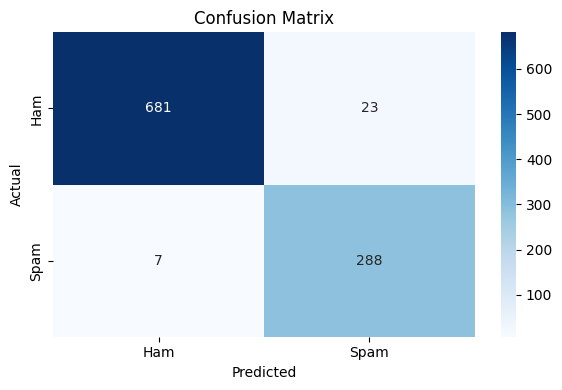

In [21]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

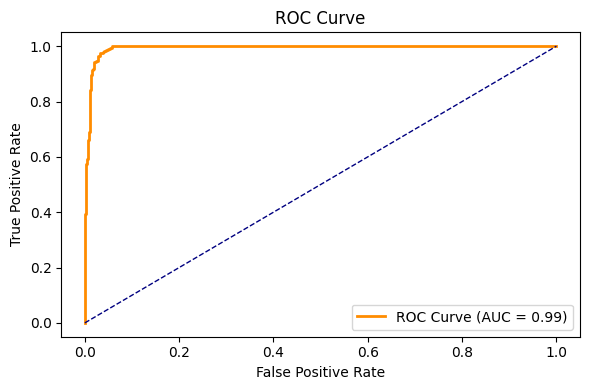

In [22]:
fpr, tpr, _ = roc_curve(Y_test, Y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()